# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

## Logistic Regression
Linear regression is used to predict values of quantities as a linear function of the input values. When predicting a discrete variable, such as whether a grid of pixel intensities represents 0 or 1, we need to classify the input values. Logistic regression is a simple classification algorithm for learning to make such decisions. It is a model that is used when the dependent variable is categorical. A few cases where logistic regression can be used are mentioned below:
- Image segmentation and categorization
- Geographic image recognition
- Handwriting recognition
- Determining whether a person is depressed based on the words of his social media posts
- Predicting the probability of a person voting for a candidate in an election

Logistic regression falls under supervised learning; it measures the relationship between the categorical dependent variable and one or more independent variables by estimating probabilities using a logistic/sigmoid function. Despite the name 'logistic regression', it is not used for machine learning regression problem where the task is to predict the real-valued output. It is a classification problem that is used to predict a binary outcome (1/0, -1/1, True/False) given a set of independent variables. Logistic regression is a bit similar to linear regression, or we can say it as a generalized linear model. In linear regression, we predict a real-valued output ' y' based on a weighted sum of input variables.

![alt text](https://d2a032ejo53cab.cloudfront.net/Glossary/RhPKYU1R/logistic.PNG "Linear")

$$ y = c \;+ \;w_{1} * \;x_{1} + \;w_{2} * \;x_{2}* \;w_{3} * \;x_{3} +... \;w_{n} * \;x_{n}$$

Linear regression aims to estimate values for the model coefficients $c$, $w_{1}$, $w_{1}$, $w_{3}$...$w_{n}$ and fit the training data with minimal squared error and predict the output y.

Logistic regression does the same thing, but with one addition. The logistic regression model computes a weighted sum of the input variables similar to the linear regression, but it runs the result through a special
non-linear function, the logistic function or sigmoid function, to produce the output y. Here, the output is binary or in the form of 0/1 or -1/1.

![alt text](https://d2a032ejo53cab.cloudfront.net/Glossary/JDilmsrZ/logistic1.PNG "Logistic")


The sigmoid/logistic function is given by the following equation:

$$ y = logistic (c \;+ \;w_{1} * \;x_{1} + \;w_{2} * \;x_{2}* \;w_{3} * \;x_{3} +... \;w_{n} * \;x_{n})$$
$$ y = 1/[1 + e^{-(c \;+ \;w_{1} * \;x_{1} + \;w_{2} * \;x_{2}* \;w_{3} * \;x_{3} +... \;w_{n} * \;x_{n})}]$$
$$ y = 1/[1 +e^{-x}]$$

As you can see in the below graph, it is an S-shaped curve that gets closer to 1 as the input variable's value increases above 0 and gets closer to 0 as the input variable decreases below 0. The output of the sigmoid function is 0.5 when the input variable is 0.

![alt text](https://d2a032ejo53cab.cloudfront.net/Glossary/CZwY5Wru/sigmoid.PNG "Sigmoid")

Reference: https://blog.quantinsti.com/machine-learning-logistic-regression-python/

In this notebook, you will perform the following steps:


1. [Import Data](#data)


2. [Logistic Regression Model](#model)


3. [Predict the Values](#predict)


4. [Plot the Result](#plot)
    
<a id='data'></a> 

## Imports & Data

We will use <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html" target="_blank"> Scikit-Learn</a> library is to perform the logistic regression. 

In [1]:
import numpy as np                 
import pandas as pd                    
import matplotlib.pyplot as plt                                       # Import matplotlib as an alias plt and set the style
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')  
from sklearn.linear_model import LogisticRegression                   # the classifier we'll fit
from sklearn.metrics import accuracy_score, confusion_matrix          # quick eval (later)
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


path = '../data/'                      
df = pd.read_csv(path + 'SPY.csv', index_col=0)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


We will understand how to choose target and predictor variables for a logistic regression model. We have two features, prev day's return, and retruns a day prior to that. And our target variable is stored in the 'target' column.

In [2]:
# Compute daily returns from 'Close'
df['return'] = df['Close'].pct_change()

# Use only PRIOR 2 day's return as the predictor (prevents look-ahead)
df['1_day_lag_returns'] = df['return'].shift(1)
df['2_day_lag_returns'] = df['return'].shift(2)

# Binary target: 1 if today's return > 0 else 0
df['target'] = (df['return'] > 0).astype(int)

# Drop the first row(s) created by pct_change/shift
df = df.dropna()

We now define our X and y. We have two features and and our target coulmn. We split the data into train and test sets.

In [3]:
# Use BOTH lagged returns as features
features = ['1_day_lag_returns', '2_day_lag_returns']
X = df[features]        
y = df['target']       

# Keep chronological order: last 20% for test
test_frac = 0.20
split = int(len(df) * (1 - test_frac))

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# checking the shape of our data sets
print("Shapes ->",
      "X_train:", X_train.shape, "y_train:", y_train.shape,
      "X_test:", X_test.shape,   "y_test:",  y_test.shape)

Shapes -> X_train: (318, 2) y_train: (318,) X_test: (80, 2) y_test: (80,)


<a id='model'></a>

## Logistic Regression Model

We will use the `LogisticRegression` function from the `sklearn.linear_model` library to create a logistic regression model.

**Syntax:**
```python
LogisticRegression(C=1e5) 

Parameters used: 

    1. C (High value of C tells the model to give more weight to the training data than complexity penalty)


In [4]:
# Create an instance of LogisticRegression and fit the data

logreg = LogisticRegression(C=1e5)  

# fit on training data
logreg.fit(X_train, y_train)

LogisticRegression(C=100000.0)

<a id='predict'></a>

## Predict & Evaluate

We will use our trained logistic regression model to predict the next-day direction (up = 1, down/flat = 0) on the **test** window.

We’ll report:
- **Accuracy** (overall hit rate)
- **Confusion Matrix** (how many ups/downs we got right)


In [5]:
# --- Predict & evaluate on the test window ---

# Class labels (0/1)
y_pred = logreg.predict(X_test)

# Probabilities for the positive class (up day)
y_proba = logreg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.6250


### How to read the confusion matrix
We print it as **rows = true class**, **columns = predicted class**:

In [6]:
cm  = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("Confusion matrix (rows=true, cols=pred):\n", cm)

Confusion matrix (rows=true, cols=pred):
 [[ 4 26]
 [ 4 46]]


## The decision-region plot

- **What’s on the axes?**  
  *x-axis* = `1_day_lag_returns`, *y-axis* = `2_day_lag_returns`.

- **Shaded regions = model prediction.**  
  The two shades show where the model predicts class **0** (down) vs **1** (up).  
  The **straight line** between them is the **decision boundary** where \(P(\text{up}) = 0.5\).

- **Dots = actual test days.**  
  Each point is a day from the **test set**; its color indicates the **true class** (0 or 1).

- **How to interpret correctness.**  
  A point lying inside the region of its own class is a **correct** prediction.  
  A point inside the opposite region is a **mistake** (false positive/negative).

- **Confidence intuition.**  
  Points **farther from the boundary** are predicted with **higher probability**; points **near the line** are more uncertain.

- **What the slope means.**  
  The tilt of the boundary shows how the two lagged returns trade off: e.g., a higher 1-day lag can offset a negative 2-day lag to still predict “up”.


|        | Pred 0 | Pred 1 |
|--------|--------|--------|
| True 0 |   TN   |   FP   |
| True 1 |   FN   |   TP   |


## The decision-region plot

- **What’s on the axes?**  
  *x-axis* = `1_day_lag_returns`, *y-axis* = `2_day_lag_returns`.

- **Shaded regions = model prediction.**  
  The two shades show where the model predicts class **0** (down) vs **1** (up).  
  The **straight line** between them is the **decision boundary** where \(P(\text{up}) = 0.5\).

- **Dots = actual test days.**  
  Each point is a day from the **test set**; its color indicates the **true class** (0 or 1).

- **How to interpret correctness.**  
  A point lying inside the region of its own class is a **correct** prediction.  
  A point inside the opposite region is a **mistake** (false positive/negative).

- **Confidence intuition.**  
  Points **farther from the boundary** are predicted with **higher probability**; points **near the line** are more uncertain.

- **What the slope means.**  
  The tilt of the boundary shows how the two lagged returns trade off: e.g., a higher 1-day lag can offset a negative 2-day lag to still predict “up”.


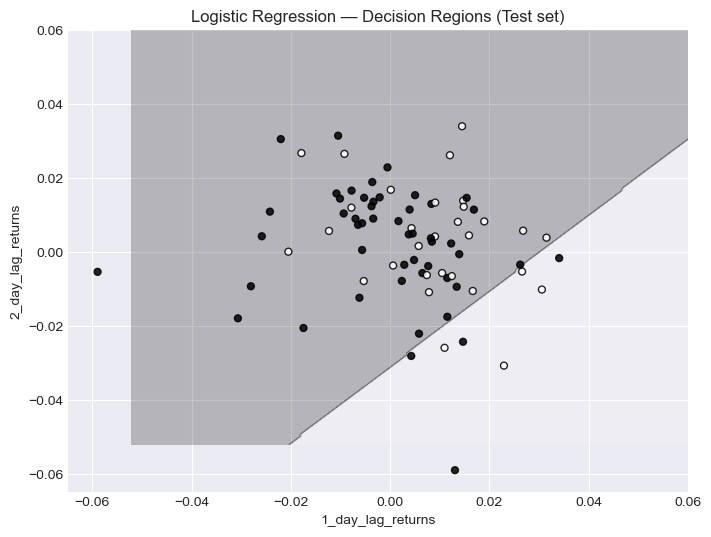

In [7]:
# --- Optional: decision boundary (binary) ---

# you trained with exactly two features
f1, f2 = features[0], features[1]

# focus on central range (avoids extreme axes)
x1_lo, x1_hi = X[f1].quantile([0.01, 0.99])
x2_lo, x2_hi = X[f2].quantile([0.01, 0.99])

xx, yy = np.meshgrid(
    np.linspace(x1_lo, x1_hi, 200),
    np.linspace(x2_lo, x2_hi, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z = logreg.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.25)                     # regions: class 0/1
plt.scatter(X_test[f1], X_test[f2], c=y_test, s=25,     # overlay test points
            edgecolor='k', alpha=0.85)
plt.xlabel(f1); plt.ylabel(f2)
plt.title('Logistic Regression — Decision Regions (Test set)')
plt.show()


## Key takeaways

- **What we built:** A simple logistic regression that predicts next-day direction (0 = down, 1 = up) using **lagged returns**.
- **No look-ahead:** We used prior-day lags as features and kept the time order; the **last 20%** of data was our **test** set.
- **Outputs:** `predict()` gives class labels; `predict_proba()[:, 1]` gives **P(up)** for each day.
- **Evaluation:** Accuracy and the **confusion matrix** show overall hits and where the model confuses ups vs downs.
- **Decision boundary:** With two features, the model draws a **straight line** separating predicted up vs down regions.
- **Limitations:** Accuracy can be inflated by class imbalance; treat results as a **teaching demo**, not trading advice.
